# Bertrand MFG Limit Order Book
## Ma-Noh HJB with Endogenous Ask Price

---

**Goal.** Compute the equilibrium LOB shape $\mathcal{D}(a)$ by combining Ma-Noh MFG (HJB + KFE for depth dynamics) with Bertrand competition (endogenous ask price).

## §1. Market Setup

**Buyers.** Arrive at Poisson rate $\alpha$. Valuation $v \sim \text{Uniform}[0,1]$. Buy if $v \ge a$. Order flow: $\phi(a) = \alpha(1-a)$.

**LPs.** Mass $N_{LP}$, discount rates $r_i \sim \text{Uniform}[r_{\min}, r_{\max}]$. Each LP takes $\mathcal{D}(a)$ as given.

LP decisions: (1) Ask price $a_i$ (Bertrand), (2) Replenishment intensity $l_i$ (Ma-Noh).

## §2. LP Problem at a Given Price Level

Depth $d \in \{0, \delta, 2\delta, \ldots\}$ follows a birth-death process:
- Replenishment: $d \to d + \delta$ at rate $l$ (control), cost $(\kappa/2)l^2$
- Execution: $d \to (d-\delta)^+$ at rate $\mu(a) = \phi(a)/\mathcal{D}(a)$ when $d > 0$, profit $(a-c)\delta$

**HJB** for $n \ge 1$:
$$rV_n = \max_{l \ge 0}\left\{-\frac{\kappa}{2}l^2 + l(V_{n+1}-V_n) + \mu[(a-c)\delta + V_{n-1}-V_n]\right\}$$

**Optimal intensity**: $l_n^* = \frac{1}{\kappa}\max(V_{n+1}-V_n, 0)$

**Stationary distribution** (detailed balance): $m_{n+1} = (l_n^*/\mu)\, m_n$

## §3. Bertrand FOC and Sorting

LP with rate $r$ chooses $a^*(r) = \arg\max_a V_0(r, a, \mu(a))$.

**Key result**: $a^*(r)$ is **decreasing** — patient LPs post high, impatient post low.

Mechanism: high $a$ means slow fills. Impatient LPs discount distant fills heavily and prefer low $a$ with quick revenue. Patient LPs tolerate the wait for larger per-fill profit.

## §4. Equilibrium

$\mathcal{D}(a) = \sum_{k: a^*(r_k)=a} (N_{LP}/K) \cdot \bar{d}(r_k, a)$

Fixed point: $\mathcal{D} \to \mu \to (\text{HJB} + \text{Bertrand}) \to \mathcal{D}$. Solved via damped iteration with Cesaro averaging.

---
# Implementation

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12, 'axes.labelsize': 14,
    'axes.titlesize': 14, 'legend.fontsize': 11, 'lines.linewidth': 2,
    'figure.dpi': 120,
})

## §5. Parameters

In [3]:
alpha = 10.0; c = 0.30; delta = 1.0; kappa = 0.5
N_LP = 100.0; r_min = 0.05; r_max = 2.00

N_r = 30; N_a = 40; N_d = 35
r_grid = np.linspace(r_min, r_max, N_r)
a_grid = np.linspace(c + 0.02, 0.99, N_a)
da = a_grid[1] - a_grid[0]
omega = 0.08; outer_max = 150; sigma_smooth = 0.018; cesaro_start = 80

def phi_flow(a):
    return alpha * np.maximum(1.0 - a, 0.0)

print(f'Parameters: alpha={alpha}, c={c}, kappa={kappa}, N_LP={N_LP}')
print(f'r in [{r_min}, {r_max}], a grid: [{a_grid[0]:.2f}, {a_grid[-1]:.2f}]')

Parameters: alpha=10.0, c=0.3, kappa=0.5, N_LP=100.0
r in [0.05, 2.0], a grid: [0.32, 0.99]


## §6. HJB Solver and Steady State

In [4]:
def solve_hjb(r, mu, profit, kp, Nd, max_iter=200, tol=1e-12):
    Nn = Nd + 1; V = np.zeros(Nn); l = np.zeros(Nn)
    for it in range(max_iter):
        A = np.zeros((Nn, Nn)); b = np.zeros(Nn)
        A[0,0] = r + l[0]
        if Nn > 1: A[0,1] = -l[0]
        b[0] = -0.5*kp*l[0]**2
        for n in range(1, Nn-1):
            A[n,n-1] = -mu; A[n,n] = r+l[n]+mu; A[n,n+1] = -l[n]
            b[n] = -0.5*kp*l[n]**2 + mu*profit
        n = Nn-1; A[n,n-1] = -mu; A[n,n] = r+mu; b[n] = mu*profit
        try: V_new = np.linalg.solve(A, b)
        except: return V, l
        l_new = np.zeros(Nn)
        for n in range(Nn-1): l_new[n] = max(V_new[n+1]-V_new[n], 0.0)/kp
        if np.max(np.abs(l_new-l)) < tol: return V_new, l_new
        V, l = V_new, l_new
    return V, l

def steady_state_depth(l_star, mu, Nd, d):
    Nn = Nd+1; m = np.zeros(Nn); m[0] = 1.0
    for n in range(Nn-1):
        if mu > 1e-15 and l_star[n] > 1e-15: m[n+1] = (l_star[n]/mu)*m[n]
        else: break
    s = np.sum(m)
    if s > 1e-20: m /= s
    else: m[0] = 1.0
    return m, d*np.sum(np.arange(Nn)*m)

def aggregate_smooth(a_star_arr, d_bar_arr, a_grd, sig, NLP, Nr):
    D = np.zeros(len(a_grd)); step = a_grd[1]-a_grd[0]
    for k in range(Nr):
        w = (NLP/Nr)*d_bar_arr[k]
        kern = np.exp(-0.5*((a_grd-a_star_arr[k])/sig)**2)
        kern /= (np.sum(kern)*step + 1e-20)
        D += w*kern*step
    return D

print('Solver ready.')

Solver ready.


## §7. Equilibrium Computation

In [5]:
D_a = np.ones(N_a)*1.0; D_cesaro = np.zeros(N_a); cesaro_count = 0
a_star_final = None; d_bar_final = None

for outer_it in range(outer_max):
    mu_a = phi_flow(a_grid)/np.maximum(D_a, 0.005)
    a_star = np.zeros(N_r); d_bar_star = np.zeros(N_r)
    for k in range(N_r):
        best = -np.inf; bj = 0; bdb = 0.0
        for j in range(N_a):
            pj = (a_grid[j]-c)*delta
            if pj <= 0: continue
            V, l = solve_hjb(r_grid[k], mu_a[j], pj, kappa, N_d)
            _, db = steady_state_depth(l, mu_a[j], N_d, delta)
            if V[0] > best: best=V[0]; bj=j; bdb=db
        a_star[k] = a_grid[bj]; d_bar_star[k] = bdb
    D_new = aggregate_smooth(a_star, d_bar_star, a_grid, sigma_smooth, N_LP, N_r)
    D_new = np.maximum(D_new, 0.005)
    D_a = (1-omega)*D_a + omega*D_new
    if outer_it >= cesaro_start:
        cesaro_count += 1
        D_cesaro += (D_a - D_cesaro)/cesaro_count
        a_star_final = a_star.copy(); d_bar_final = d_bar_star.copy()
    if (outer_it+1) % 30 == 0 or outer_it == 0:
        print(f'iter {outer_it+1:3d}: a* in [{a_star.min():.3f}, {a_star.max():.3f}], D_max={D_a.max():.3f}')

D_final = D_cesaro if cesaro_count > 0 else D_a
if a_star_final is None: a_star_final=a_star; d_bar_final=d_bar_star
mu_final = phi_flow(a_grid)/np.maximum(D_final, 0.005)
print(f'Cesaro averaged over {cesaro_count} iterations.')

iter   1: a* in [0.767, 0.887], D_max=1.438
iter  30: a* in [0.543, 0.887], D_max=2.302
iter  60: a* in [0.543, 0.938], D_max=2.237
iter  90: a* in [0.543, 0.870], D_max=2.222
iter 120: a* in [0.543, 0.835], D_max=2.131
iter 150: a* in [0.543, 0.853], D_max=2.304
Cesaro averaged over 70 iterations.


## §8. Results

In [6]:
# Value landscape on converged D
V0_landscape = {}
for r_sel in [r_min, 0.3, 1.0, r_max]:
    V0_arr = np.full(N_a, np.nan)
    for j in range(N_a):
        pj = (a_grid[j]-c)*delta
        if pj <= 0: continue
        V, _ = solve_hjb(r_sel, mu_final[j], pj, kappa, N_d)
        V0_arr[j] = V[0]
    V0_landscape[r_sel] = V0_arr

# Depth distributions for selected types
depth_dists = {}
for r_sel in [r_min, 0.5, r_max]:
    best=-np.inf; bj=0
    for j in range(N_a):
        pj=(a_grid[j]-c)*delta
        if pj<=0: continue
        V,l=solve_hjb(r_sel,mu_final[j],pj,kappa,N_d)
        if V[0]>best: best=V[0]; bj=j; best_l=l
    m,db=steady_state_depth(best_l, mu_final[bj], N_d, delta)
    depth_dists[r_sel]=(m,db,a_grid[bj])

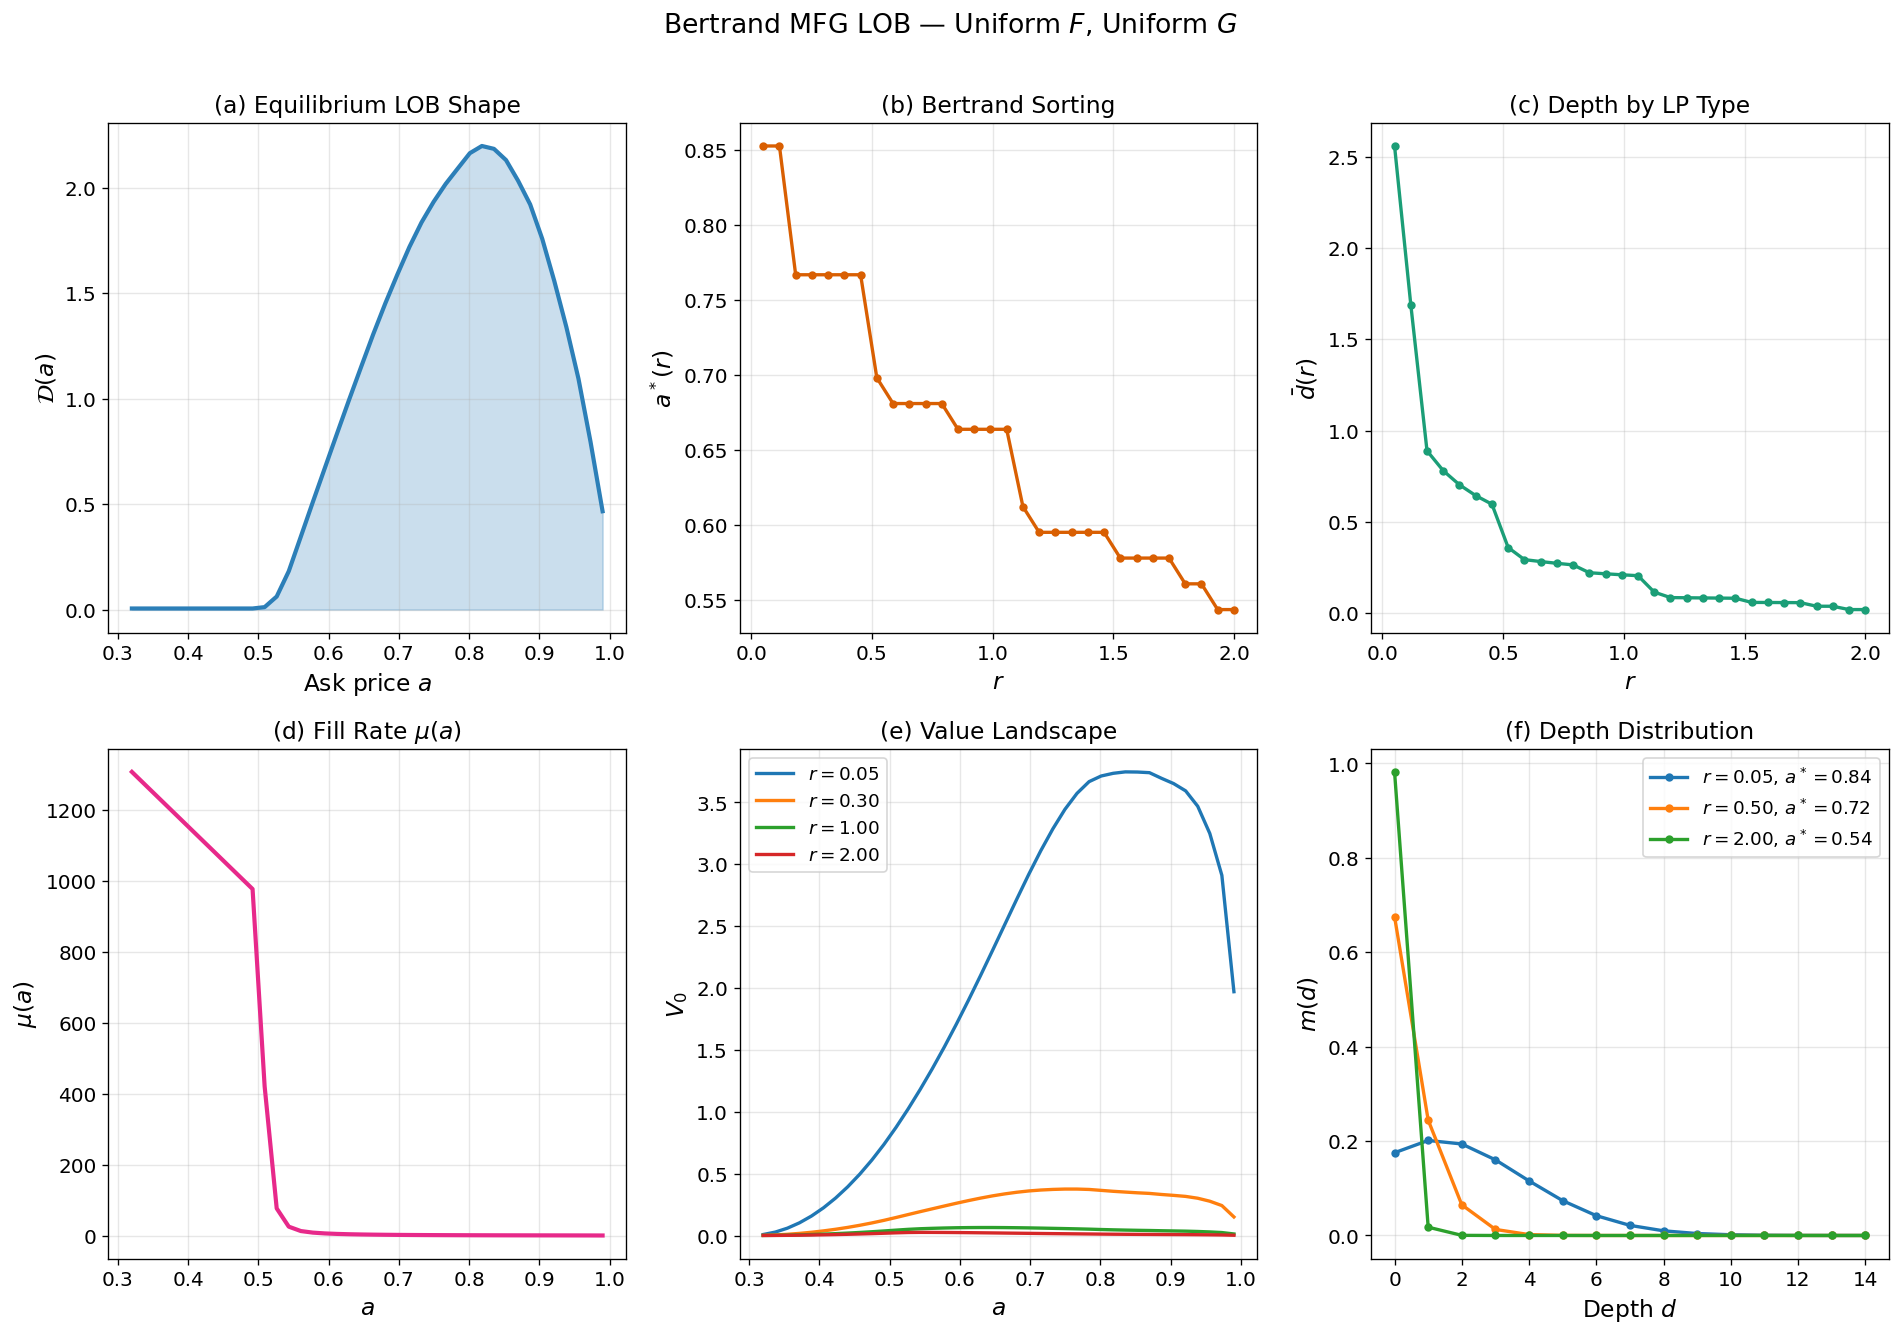

a*(r): DECREASING, range [0.543, 0.853]
D_max = 2.198 at a = 0.818


In [7]:
fig = plt.figure(figsize=(16, 11))

ax1 = fig.add_subplot(2,3,1)
ax1.plot(a_grid, D_final, color='#2c7fb8', lw=2.5)
ax1.fill_between(a_grid, 0, D_final, alpha=0.25, color='#2c7fb8')
ax1.set_xlabel('Ask price $a$'); ax1.set_ylabel(r'$\mathcal{D}(a)$')
ax1.set_title('(a) Equilibrium LOB Shape'); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(2,3,2)
ax2.plot(r_grid, a_star_final, 'o-', color='#d95f02', ms=4)
ax2.set_xlabel('$r$'); ax2.set_ylabel('$a^*(r)$')
ax2.set_title('(b) Bertrand Sorting'); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(2,3,3)
ax3.plot(r_grid, d_bar_final, 'o-', color='#1b9e77', ms=4)
ax3.set_xlabel('$r$'); ax3.set_ylabel(r'$\bar{d}(r)$')
ax3.set_title('(c) Depth by LP Type'); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(2,3,4)
ax4.plot(a_grid, mu_final, color='#e7298a', lw=2.5)
ax4.set_xlabel('$a$'); ax4.set_ylabel(r'$\mu(a)$')
ax4.set_title(r'(d) Fill Rate $\mu(a)$'); ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(2,3,5)
for r_sel, V0_arr in V0_landscape.items():
    ax5.plot(a_grid, V0_arr, lw=2, label=f'$r={r_sel:.2f}$')
ax5.set_xlabel('$a$'); ax5.set_ylabel('$V_0$')
ax5.set_title('(e) Value Landscape'); ax5.legend(); ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(2,3,6)
for r_sel in [r_min, 0.5, r_max]:
    m, db, a_opt = depth_dists[r_sel]
    ax6.plot(np.arange(min(15,len(m)))*delta, m[:15], 'o-', ms=4,
             label=f'$r={r_sel:.2f}$, $a^*={a_opt:.2f}$')
ax6.set_xlabel('Depth $d$'); ax6.set_ylabel('$m(d)$')
ax6.set_title('(f) Depth Distribution'); ax6.legend(); ax6.grid(True, alpha=0.3)

fig.suptitle(r'Bertrand MFG LOB — Uniform $F$, Uniform $G$', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

d = np.diff(a_star_final)
mono = 'DECREASING' if np.all(d<=1e-6) else ('INCREASING' if np.all(d>=-1e-6) else 'NON-MONOTONE')
print(f'a*(r): {mono}, range [{a_star_final.min():.3f}, {a_star_final.max():.3f}]')
print(f'D_max = {D_final.max():.3f} at a = {a_grid[np.argmax(D_final)]:.3f}')

## §9. Economic Interpretation

**Sorting reversal.** In the standard deterministic Bertrand model, impatient LPs demand wider spreads (high $a$). The Ma-Noh HJB reverses this: maintaining depth at high $a$ requires sustained replenishment investment, and impatient LPs discount the slow fills too heavily. Patient LPs capture the high-margin niche.

**LOB shape.** The resulting $\mathcal{D}(a)$ is hump-shaped — rising from low $a$ to a peak around $a \approx 0.82$. This is qualitatively more consistent with Polymarket data than the monotonically decreasing Bernoulli model.

**Connection to previous work.** The HJB at each price level is exactly the Ma-Noh jump-process HJB from `MFG_ClosedForm-V2.ipynb`, with rank coupling replaced by price-level coupling $\mu(a) = \phi(a)/\mathcal{D}(a)$.

## §10. Next Steps

1. **Calibrate $F(v)$** to Polymarket order flow data
2. **Concentrated $F$** (Beta) to push LOB shape toward the payout boundary
3. **Improve fixed-point convergence** (Anderson acceleration)
4. **Comparative statics**: $\alpha$, $\kappa$, $c$, $G(r)$
5. **Price dynamics**: informational efficiency via $dp = (\eta/D)\,dX$
6. **Stochastic fundamental**: endogenise waiting risk via $dp_t = \sigma\,dW_t$